In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("it_job_apps.csv")

In [ ]:
print(df.head())

  Application_ID Candidate_Name  Gender  Age       City        State  \
0        APP0001    Anya Butala    Male   27  Ahmedabad      Gujarat   
1        APP0002      Hansh Bal  Female   24    Gurgaon      Haryana   
2        APP0003   Ahana  Yadav    Male   30       Pune  Maharashtra   
3        APP0004      Urvi Bora  Female   38    Chennai   Tamil Nadu   
4        APP0005  Alisha Mammen  Female   34  Hyderabad    Telangana   

  Qualification        Specialization                       College_Name  \
0          B.E.      Computer Science  Dayal, Walia and Gandhi Institute   
1        B.Tech  Software Engineering              Cherian PLC Institute   
2        B.Tech          Data Science   Wagle, Barad and Samra Institute   
3          B.E.       Cloud Computing        Banerjee and Sons Institute   
4           BCA  Software Engineering            Sanghvi Group Institute   

   Graduation_Year  ...  Expected_Salary_LPA Current_Salary_LPA  \
0             2024  ...                 12.

In [ ]:
print(df.shape)

(505, 26)


In [ ]:
print(df.columns)

Index(['Application_ID', 'Candidate_Name', 'Gender', 'Age', 'City', 'State',
       'Qualification', 'Specialization', 'College_Name', 'Graduation_Year',
       'Experience_Years', 'Previous_Company', 'Applied_Role', 'Department',
       'Skills', 'Certification', 'Expected_Salary_LPA', 'Current_Salary_LPA',
       'Notice_Period_Days', 'Application_Date', 'Interview_Score',
       'Technical_Test_Score', 'Communication_Score', 'Status', 'Work_Mode',
       'Preferred_Location'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Application_ID        505 non-null    object 
 1   Candidate_Name        505 non-null    object 
 2   Gender                505 non-null    object 
 3   Age                   505 non-null    int64  
 4   City                  505 non-null    object 
 5   State                 505 non-null    object 
 6   Qualification         505 non-null    object 
 7   Specialization        505 non-null    object 
 8   College_Name          505 non-null    object 
 9   Graduation_Year       505 non-null    int64  
 10  Experience_Years      505 non-null    int64  
 11  Previous_Company      354 non-null    object 
 12  Applied_Role          505 non-null    object 
 13  Department            505 non-null    object 
 14  Skills                505 non-null    object 
 15  Certification         3

In [ ]:
print(df.describe())

              Age  Graduation_Year  Experience_Years  Expected_Salary_LPA  \
count  505.000000       505.000000        505.000000           505.000000   
mean    29.536634      2021.518812          3.558416            19.613465   
std      5.290672         3.382985          3.247260             8.804169   
min     21.000000      2014.000000          0.000000             4.000000   
25%     25.000000      2019.000000          1.000000            11.900000   
50%     29.000000      2022.000000          3.000000            19.700000   
75%     35.000000      2024.000000          6.000000            27.000000   
max     38.000000      2026.000000         10.000000            35.000000   

       Current_Salary_LPA  Notice_Period_Days  Interview_Score  \
count          387.000000          505.000000       235.000000   
mean            16.210078           49.396040        77.429787   
std              8.792259           25.324904        10.215539   
min             -0.900000           15.000

**Data Cleaning**

In [ ]:
print(df.isnull().sum())

Application_ID            0
Candidate_Name            0
Gender                    0
Age                       0
City                      0
State                     0
Qualification             0
Specialization            0
College_Name              0
Graduation_Year           0
Experience_Years          0
Previous_Company        151
Applied_Role              0
Department                0
Skills                    0
Certification           118
Expected_Salary_LPA       0
Current_Salary_LPA      118
Notice_Period_Days        0
Application_Date          0
Interview_Score         270
Technical_Test_Score    274
Communication_Score     239
Status                    0
Work_Mode                 0
Preferred_Location        0
dtype: int64


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Previous_Company        151
Certification           118
Current_Salary_LPA      118
Interview_Score         270
Technical_Test_Score    274
Communication_Score     239
dtype: int64


In [ ]:
df['Certification'] = df['Certification'].fillna("Not Certified")

In [ ]:
df['Interview_Score'] = df['Interview_Score'].fillna(
    df['Interview_Score'].mean()
)

In [ ]:
df['Technical_Test_Score'] = df['Technical_Test_Score'].fillna(
    df['Technical_Test_Score'].mean()
)

In [ ]:
df['Communication_Score'] = df['Communication_Score'].fillna(
    df['Communication_Score'].mean()
)

In [ ]:
df['Current_Salary_LPA'] = df['Current_Salary_LPA'].fillna(0)

In [ ]:
df['Previous_Company'] = df['Previous_Company'].replace("", "Fresher")

In [ ]:
print(df.duplicated().sum())

5


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.shape)

(500, 26)


In [ ]:
df['Application_Date'] = pd.to_datetime(df['Application_Date'])

In [ ]:
print(df.dtypes)

Application_ID                  object
Candidate_Name                  object
Gender                          object
Age                              int64
City                            object
State                           object
Qualification                   object
Specialization                  object
College_Name                    object
Graduation_Year                  int64
Experience_Years                 int64
Previous_Company                object
Applied_Role                    object
Department                      object
Skills                          object
Certification                   object
Expected_Salary_LPA            float64
Current_Salary_LPA             float64
Notice_Period_Days               int64
Application_Date        datetime64[ns]
Interview_Score                float64
Technical_Test_Score           float64
Communication_Score            float64
Status                          object
Work_Mode                       object
Preferred_Location       

In [ ]:
df['Candidate_Name'] = df['Candidate_Name'].str.strip()

df['City'] = df['City'].str.strip()

df['Applied_Role'] = df['Applied_Role'].str.strip()

In [ ]:
df['Expected_Salary_LPA'] = df['Expected_Salary_LPA'].astype(float)

df['Current_Salary_LPA'] = df['Current_Salary_LPA'].astype(float)

**Data Analysis**

In [ ]:
print("Total Applications:", len(df))

Total Applications: 500


In [ ]:
selected = df[df['Status'] == 'Selected']

print("Selected Candidates:", len(selected))

Selected Candidates: 160


In [ ]:
selection_ratio = (
    len(selected) / len(df)
) * 100

print("Selection Percentage:", selection_ratio)

Selection Percentage: 32.0


In [ ]:
print(df['Applied_Role'].value_counts())

Applied_Role
Java Developer               40
Cyber Security Analyst       35
Data Analyst                 34
Business Analyst             33
Frontend Developer           32
Cloud Engineer               30
Machine Learning Engineer    29
DevOps Engineer              29
AI Engineer                  28
Data Scientist               28
Database Administrator       27
Python Developer             27
Backend Developer            26
QA Engineer                  24
BI Developer                 24
Full Stack Developer         20
Product Analyst              18
Project Manager              16
Name: count, dtype: int64


In [ ]:
print(df['Applied_Role'].value_counts().head(5))

Applied_Role
Java Developer            40
Cyber Security Analyst    35
Data Analyst              34
Business Analyst          33
Frontend Developer        32
Name: count, dtype: int64


In [ ]:
print(df['Expected_Salary_LPA'].mean())

19.587400000000002


In [ ]:
print(df['Expected_Salary_LPA'].max())

35.0


In [ ]:
print(df['Expected_Salary_LPA'].min())

4.0


In [ ]:
print(df['Experience_Years'].mean())

3.576


In [ ]:
freshers = df[df['Experience_Years'] == 0]

print("Freshers:", len(freshers))

Freshers: 117


In [ ]:
experienced = df[df['Experience_Years'] > 0]

print("Experienced Candidates:", len(experienced))

Experienced Candidates: 383


In [ ]:
print(df['Gender'].value_counts())

Gender
Male      267
Female    233
Name: count, dtype: int64


In [ ]:
print(df['Work_Mode'].value_counts())

Work_Mode
Remote    168
Onsite    167
Hybrid    165
Name: count, dtype: int64


In [38]:
print(df['Preferred_Location'].value_counts())

Preferred_Location
Indore         49
Chennai        43
Ahmedabad      38
Kolkata        37
Bangalore      36
Delhi          36
Jaipur         36
Kochi          33
Mumbai         31
Hyderabad      30
Noida          29
Gurgaon        27
Pune           26
Nagpur         26
Bhubaneswar    23
Name: count, dtype: int64


In [39]:
print(df['State'].value_counts())

State
Maharashtra       98
Rajasthan         42
Delhi             38
West Bengal       37
Gujarat           35
Karnataka         34
Uttar Pradesh     34
Kerala            34
Odisha            33
Tamil Nadu        32
Haryana           30
Madhya Pradesh    29
Telangana         24
Name: count, dtype: int64


In [40]:
print(df['City'].value_counts())

City
Nagpur         42
Jaipur         42
Delhi          38
Kolkata        37
Ahmedabad      35
Kochi          34
Noida          34
Bangalore      34
Bhubaneswar    33
Chennai        32
Gurgaon        30
Indore         29
Mumbai         29
Pune           27
Hyderabad      24
Name: count, dtype: int64


In [41]:
salary_by_role = df.groupby(
    'Applied_Role'
)['Expected_Salary_LPA'].mean()

print(salary_by_role)

Applied_Role
AI Engineer                  19.782143
BI Developer                 18.454167
Backend Developer            19.426923
Business Analyst             21.257576
Cloud Engineer               17.706667
Cyber Security Analyst       18.200000
Data Analyst                 21.232353
Data Scientist               18.210714
Database Administrator       20.277778
DevOps Engineer              17.217241
Frontend Developer           22.071875
Full Stack Developer         21.330000
Java Developer               18.980000
Machine Learning Engineer    19.037931
Product Analyst              20.166667
Project Manager              21.750000
Python Developer             19.874074
QA Engineer                  18.820833
Name: Expected_Salary_LPA, dtype: float64


In [42]:
interview_by_role = df.groupby(
    'Applied_Role'
)['Interview_Score'].mean()

print(interview_by_role)

Applied_Role
AI Engineer                  77.638450
BI Developer                 76.780319
Backend Developer            76.440262
Business Analyst             80.217150
Cloud Engineer               78.400851
Cyber Security Analyst       75.359878
Data Analyst                 78.349312
Data Scientist               76.332371
Database Administrator       75.243972
DevOps Engineer              77.099193
Frontend Developer           79.969282
Full Stack Developer         75.714894
Java Developer               77.679362
Machine Learning Engineer    76.498166
Product Analyst              77.992671
Project Manager              77.714894
Python Developer             77.688416
QA Engineer                  77.554078
Name: Interview_Score, dtype: float64


In [43]:
print(df['Department'].value_counts())

Department
Software Development     93
Analytics                86
Cloud                    59
AI/ML                    57
Web Development          52
Security                 35
Business Intelligence    33
Database                 27
Testing                  24
Product                  18
Management               16
Name: count, dtype: int64


In [44]:
top_candidates = df.sort_values(
    by='Interview_Score',
    ascending=False
)

print(top_candidates.head(10))

    Application_ID      Candidate_Name  Gender  Age         City  \
87         APP0088         Azad Sangha    Male   37    Ahmedabad   
254        APP0255      Manikya Sahota    Male   29    Bangalore   
11         APP0012      Ryan Ahluwalia  Female   27  Bhubaneswar   
285        APP0286        Advika Shere  Female   30      Kolkata   
430        APP0431   Divyansh Varghese  Female   35        Noida   
207        APP0208           Biju Sama    Male   30        Delhi   
65         APP0066  Hrishita Choudhary    Male   34       Mumbai   
322        APP0323           Jiya Bath    Male   30       Nagpur   
146        APP0147        Purab Cheema    Male   25       Jaipur   
109        APP0110         Vidur Koshy  Female   31    Ahmedabad   

             State      Qualification          Specialization  \
87         Gujarat               B.E.          Cyber Security   
254      Karnataka                MCA            Data Science   
11          Odisha  M.Sc Data Science    Software Engine

In [45]:
high_salary = df[
    df['Expected_Salary_LPA'] > 20
]

print(high_salary.head())

  Application_ID      Candidate_Name  Gender  Age       City           State  \
1        APP0002           Hansh Bal  Female   24    Gurgaon         Haryana   
2        APP0003        Ahana  Yadav    Male   30       Pune     Maharashtra   
4        APP0005       Alisha Mammen  Female   34  Hyderabad       Telangana   
5        APP0006        Romil Luthra    Male   24     Indore  Madhya Pradesh   
6        APP0007  Ritvik Chakraborty  Female   26     Nagpur     Maharashtra   

  Qualification        Specialization                      College_Name  \
1        B.Tech  Software Engineering             Cherian PLC Institute   
2        B.Tech          Data Science  Wagle, Barad and Samra Institute   
4           BCA  Software Engineering           Sanghvi Group Institute   
5           MBA        Cyber Security            Dubey-Sachar Institute   
6           BCA      Computer Science            Sankaran LLC Institute   

   Graduation_Year  ...  Expected_Salary_LPA Current_Salary_LPA  \
1

In [46]:
remote = df[
    df['Work_Mode'] == 'Remote'
]

print(remote.head())

   Application_ID      Candidate_Name  Gender  Age         City        State  \
6         APP0007  Ritvik Chakraborty  Female   26       Nagpur  Maharashtra   
9         APP0010       Saanvi Kalita  Female   28         Pune  Maharashtra   
10        APP0011          Taran Gara    Male   38        Delhi        Delhi   
14        APP0015     Vardaniya Madan  Female   24  Bhubaneswar       Odisha   
16        APP0017           Urvi Gade    Male   29    Bangalore    Karnataka   

        Qualification      Specialization                     College_Name  \
6                 BCA    Computer Science           Sankaran LLC Institute   
9   M.Sc Data Science  Business Analytics              Dixit PLC Institute   
10             M.Tech             AI & ML      Upadhyay and Sons Institute   
14             B.Tech        Data Science  Barad, Manda and Wali Institute   
16               B.E.  Business Analytics         Dewan and Sons Institute   

    Graduation_Year  ...  Expected_Salary_LPA Curr

In [47]:
selected = df[
    df['Status'] == 'Selected'
]

print(selected.head())

  Application_ID     Candidate_Name  Gender  Age         City           State  \
3        APP0004          Urvi Bora  Female   38      Chennai      Tamil Nadu   
5        APP0006       Romil Luthra    Male   24       Indore  Madhya Pradesh   
7        APP0008  Kiara Subramanian  Female   38  Bhubaneswar          Odisha   
8        APP0009       Anahita Kota    Male   31       Jaipur       Rajasthan   
9        APP0010      Saanvi Kalita  Female   28         Pune     Maharashtra   

       Qualification      Specialization                 College_Name  \
3               B.E.     Cloud Computing  Banerjee and Sons Institute   
5                MBA      Cyber Security       Dubey-Sachar Institute   
7               B.E.      Cyber Security     Bhatt-Upadhyay Institute   
8             B.Tech        Data Science          Sen-Koshy Institute   
9  M.Sc Data Science  Business Analytics          Dixit PLC Institute   

   Graduation_Year  ...  Expected_Salary_LPA Current_Salary_LPA  \
3      

In [48]:
role_selection = df.groupby(
    'Applied_Role'
)['Status'].value_counts()

print(role_selection)

Applied_Role               Status  
AI Engineer                Pending     10
                           Rejected    10
                           Selected     8
BI Developer               Pending     11
                           Rejected     8
                           Selected     5
Backend Developer          Pending     10
                           Selected    10
                           Rejected     6
Business Analyst           Rejected    13
                           Selected    12
                           Pending      8
Cloud Engineer             Pending     13
                           Rejected     9
                           Selected     8
Cyber Security Analyst     Selected    15
                           Pending     13
                           Rejected     7
Data Analyst               Pending     14
                           Rejected    11
                           Selected     9
Data Scientist             Pending     11
                           Selected     

In [49]:
status_scores = df.groupby('Status')[
    ['Interview_Score',
     'Technical_Test_Score',
     'Communication_Score']
].mean()

print(status_scores)

          Interview_Score  Technical_Test_Score  Communication_Score
Status                                                              
Pending         77.028599             78.601320            77.555005
Rejected        77.882622             79.233202            76.276187
Selected        77.421197             78.352760            77.127538


In [50]:
correlation = df[
    ['Experience_Years',
     'Expected_Salary_LPA',
     'Interview_Score',
     'Technical_Test_Score']
].corr()

print(correlation)

                      Experience_Years  Expected_Salary_LPA  Interview_Score  \
Experience_Years              1.000000            -0.058857        -0.045069   
Expected_Salary_LPA          -0.058857             1.000000         0.011864   
Interview_Score              -0.045069             0.011864         1.000000   
Technical_Test_Score          0.073466             0.035032        -0.015295   

                      Technical_Test_Score  
Experience_Years                  0.073466  
Expected_Salary_LPA               0.035032  
Interview_Score                  -0.015295  
Technical_Test_Score              1.000000  


Export data

In [51]:
df.to_csv(
    "cleaned_it_job_applications.csv",
    index=False
)

**Visualization**

In [52]:
import matplotlib.pyplot as plt

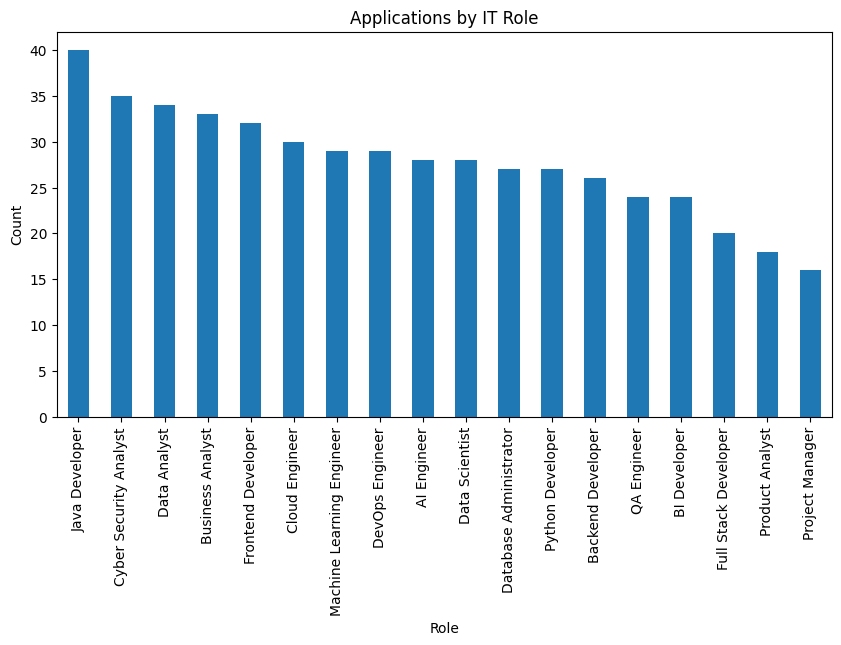

In [53]:
df['Applied_Role'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Applications by IT Role")
plt.xlabel("Role")
plt.ylabel("Count")

plt.show()

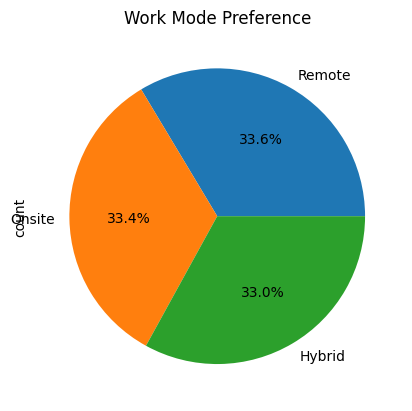

In [54]:
df['Work_Mode'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Work Mode Preference")

plt.show()

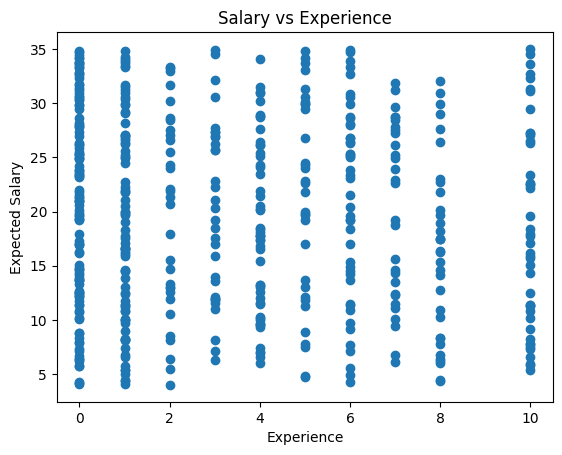

In [55]:
plt.scatter(
    df['Experience_Years'],
    df['Expected_Salary_LPA']
)

plt.xlabel("Experience")
plt.ylabel("Expected Salary")

plt.title("Salary vs Experience")

plt.show()